In [2]:
import numpy as np
from neowise_ML import score, plot_cutout

## Visualize cutouts

The data folder contains some example cutouts of each class, cropped and pre-processed from the unWISE catalog to $\pm 3\sigma$ of the median pixel value, and scaled between 0-1. Cutouts must be 61x61 px and properly pre-processed in order for scoring to be accurate. We can visualize what these images look like with the ```plot_cutout``` function:

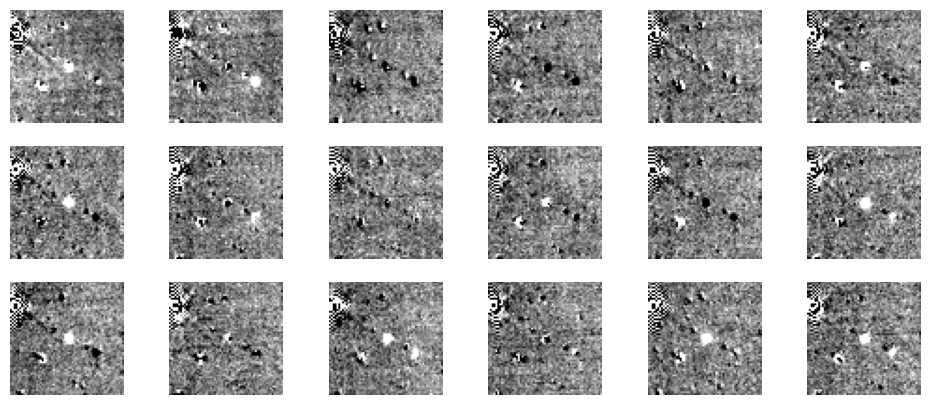

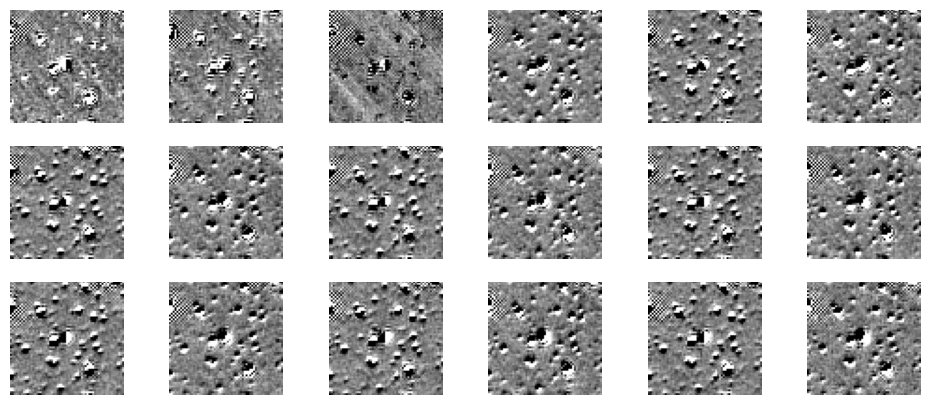

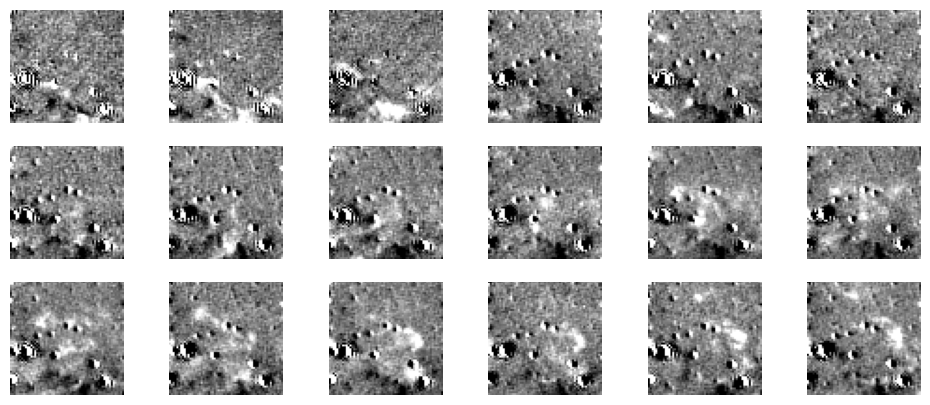

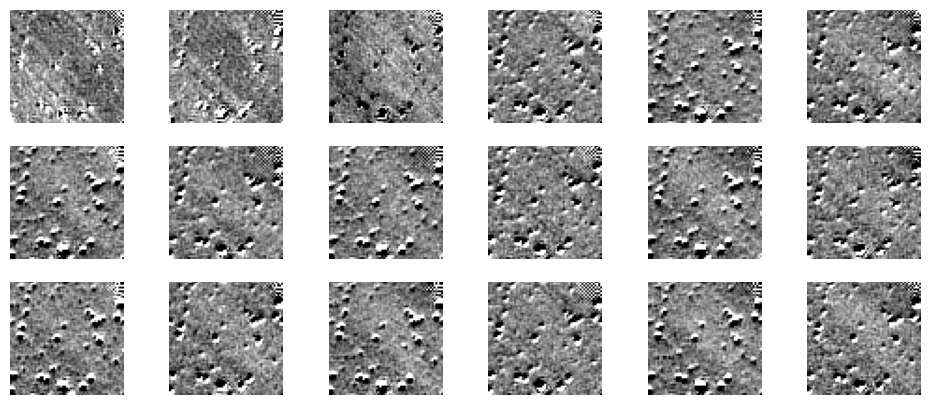

In [3]:
data_folder = "../data/"

file = np.load(data_folder + "test_18epochcutouts.npz")
cutouts = file["data"]
cutouts_plot = np.moveaxis(cutouts, 3, 1) # switch dimensions to make plotting easier

for i in cutouts_plot[::-2]:
    plot_cutout(i, num_epochs=18);

In order, there are examples of each class: reals, highpm, echo, and artifact.

## Score cutouts

Scoring can either be done on difference cutouts of 18 epochs (```model = "echo"```), or triplet cutouts (science, reference, and difference images; ```model = "triplet"```). You can enable output of the raw probabilities with ```raw_logits = True```, otherwise the classes are marked as the following: reals: 0, highpm: 1, echo: 2, artifact: 3


In [4]:
y_probs = score(data = cutouts, model = "echo", raw_logits = True)
print(y_probs)

[[5.4991008e-03 1.7113009e-03 1.0305938e-04 9.9268651e-01]
 [5.3893246e-02 3.7331213e-03 1.6855713e-02 9.2551786e-01]
 [6.4483515e-06 1.3869010e-08 9.9866939e-01 1.3242558e-03]
 [2.5858253e-04 6.1935282e-07 9.9761981e-01 2.1208681e-03]
 [1.0445919e-04 9.9688977e-01 6.5915801e-06 2.9992035e-03]
 [2.3458889e-04 9.9975544e-01 5.4406161e-07 9.4092729e-06]
 [9.9972385e-01 2.7059633e-04 5.7200563e-08 5.4834882e-06]
 [9.9999189e-01 4.5337492e-06 1.4165920e-07 3.4643642e-06]]


From the raw probabilities, we can select the top class by selecting for the largest probability in each row.

In [6]:
y_prob = np.argmax(y_probs, axis = 1)
print(y_prob)

[3 3 2 2 1 1 0 0]
